In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4090 Laptop GPU


In [2]:
import os
# Ortam değişkenlerini Jupyter'de hemen başta ayarla
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
os.environ['MKL_THREADING_LAYER'] = 'GNU'  # Alternatif olarak 'INTEL' deneyebilirsin

### Required Package Installation

In [4]:
# Required packages
# Core numerical & computation libraries
import torch
torch.manual_seed(1606) 
import numpy as np
np.random.seed(1606)    
import random
random.seed(1606)     
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams

import scanpy as sc
import scMulan
from scMulan import GeneSymbolUniform, scMulanTokenizer

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### Path Configuration

In [5]:
base_dir   = Path.cwd()                                     
data_path  = base_dir / "TCGA_mrna_tpm_unstranded.h5ad"
ckp_path   = base_dir / "ckpt/ckpt_scMulan.pt"
metainfo_path = base_dir / "scMulan/utils/meta_info.pt"

results_dir = base_dir / "finetuning_results"
results_dir.mkdir(parents=True, exist_ok=True)
run_name = "scMulan_pretrained_embedding"
out_file = results_dir / f"{run_name}.csv"
pt_file = results_dir / f"{run_name}.pt"

### Loading and Preprocessing Input Data

In [6]:
TCGA = sc.read(data_path)

In [7]:
TCGA = GeneSymbolUniform(input_adata = TCGA,
                         output_dir = "Data/",
                         output_prefix = "tcga")

The shape of query data is: (9987, 60694)
The length of reference gene_list is: 42117
Performing gene symbol uniform, this step may take several minutes


Processing: 100%|███████████████████████████████████████████████████████████████| 60694/60694 [00:53<00:00, 1137.31it/s]

Building output data, this step may take several minutes



Processing: 100%|███████████████████████████████████████████████████████████████| 39010/39010 [00:15<00:00, 2476.21it/s]


Shape of output data is (9987, 42117). It should have 42117 genes with cell number unchanged.
h5ad file saved in: Data/tcga_uniformed.h5ad
report file saved in: Data/tcga_report.csv


In [8]:
sc.pp.normalize_total(TCGA, target_sum = 1e4) 
sc.pp.log1p(TCGA)

### Pre-trained Embedding

In [9]:
scml = scMulan.model_inference(ckp_path, TCGA, meta_info_path=metainfo_path)
base_process = scml.cuda_count()

number of parameters: 368.80M
✅ adata passed check
👸 scMulan is ready
scMulan is currently available to 1 GPUs.


In [10]:
#scml.get_cell_types_and_embds_for_adata(parallel = True, n_process=2)
scml.get_cell_types_and_embds_for_adata(parallel = False)

⏳ Collecting cell embeddings for each cell: 100%|████████████████████████████████| 9987/9987 [1:21:46<00:00,  2.04it/s]


In [11]:
embeddings = scml.adata.obsm["X_scMulan"].copy()
TCGA.obsm["X_scMulan"] = embeddings

In [12]:
def embedding_plots(
    data,
    classes,
    random_state=1606,
    figsize=(9, 5),
    point_size=10,
    alpha=0.7,
    legend_title="Cohort"
):
    le = LabelEncoder()
    y_encoded = le.fit_transform(classes)
    palette = sns.color_palette("tab20", 20) + sns.color_palette("Set3", 13)

    tsne_model = TSNE(
        n_components=2,      
        perplexity=30,       
        random_state=random_state,   
        metric="euclidean"
    )
    tsne_embeddings = tsne_model.fit_transform(data)

    umap_model = umap.UMAP(
        random_state=random_state,
        metric="euclidean",
        n_neighbors=10,
        min_dist=0.5
    )
    umap_embeddings = umap_model.fit_transform(data)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=y_encoded, 
                    cmap="tab20", s=point_size, alpha=alpha)
    axes[0].set_title("UMAP", fontsize=11)

    axes[1].scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=y_encoded, 
                    cmap="tab20", s=point_size, alpha=alpha)
    axes[1].set_title("t-SNE", fontsize=11)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1) 
    # ----------------------------------------------

    labels = [str(x).split("-", 1)[-1] for x in le.classes_]
    handles = [plt.Line2D([], [], marker="o", color=palette[i % len(palette)], 
               linestyle="", markersize=6, label=label) for i, label in enumerate(labels)]

    fig.legend(handles=handles, title=legend_title, loc="lower center", 
               bbox_to_anchor=(0.5, -0.1), ncol=min(len(labels), 6), 
               prop={"size": 7}, frameon=False)

    plt.subplots_adjust(wspace=0.15)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

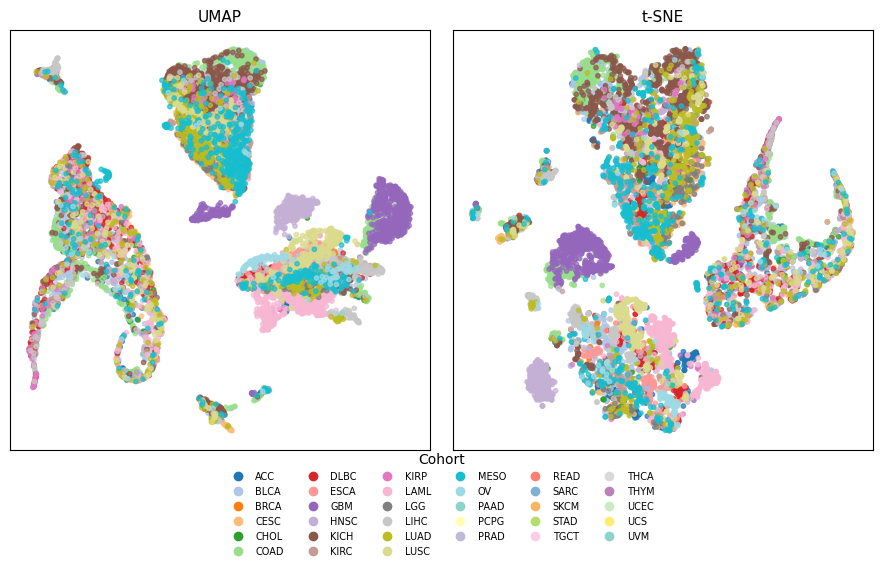

In [13]:
embedding_plots(TCGA.obsm["X_scMulan"],TCGA.obs.cohort)

### Multiclass Classification

In [14]:
X_train, X_test, y_train, y_test = train_test_split(TCGA.obsm["X_scMulan"], TCGA.obs.cohort,
                                                    test_size = 0.2, random_state = 1234,
                                                    shuffle = True, stratify = TCGA.obs.cohort)

kfold_cv = StratifiedKFold(n_splits = 4, shuffle = True, random_state = 1234)

param_grid = {"n_estimators": [100, 200, 300]}

grid_search = GridSearchCV(RandomForestClassifier(random_state = 1234), param_grid = param_grid, cv = kfold_cv)

grid_search.fit(X_train, y_train)

y_train_hat = grid_search.predict(X_train)
print(accuracy_score(y_train, y_train_hat))

y_test_hat = grid_search.predict(X_test)
print(accuracy_score(y_test, y_test_hat))

1.0
0.7042042042042042


In [17]:
# Recording Embedding Results 
np.savetxt(fname = str(out_file), 
           X = TCGA.obsm["X_scMulan"], delimiter = ",")